Vocab     : 59
Train     : 3000 | Val: 1000 | Test: 1000

Total parameters: 107,323
[OK] Parameter constraint passed

[Full Training] epochs=10
Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 108ms/step - accuracy: 0.1637 - loss: 3.2458 - val_accuracy: 0.2395 - val_loss: 2.8957
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2807 - loss: 2.6112 - val_accuracy: 0.3111 - val_loss: 2.4256
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3317 - loss: 2.3181 - val_accuracy: 0.3471 - val_loss: 2.2420
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3571 - loss: 2.1816 - val_accuracy: 0.3686 - val_loss: 2.1375
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3797 - loss: 2.0830 - val_accuracy: 0.3943 - val_loss: 2.0399
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4065 - loss: 1.9833 - val_accuracy: 0.4164 - val_loss: 1.9440
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4330 - loss: 1.8830 - val_accura

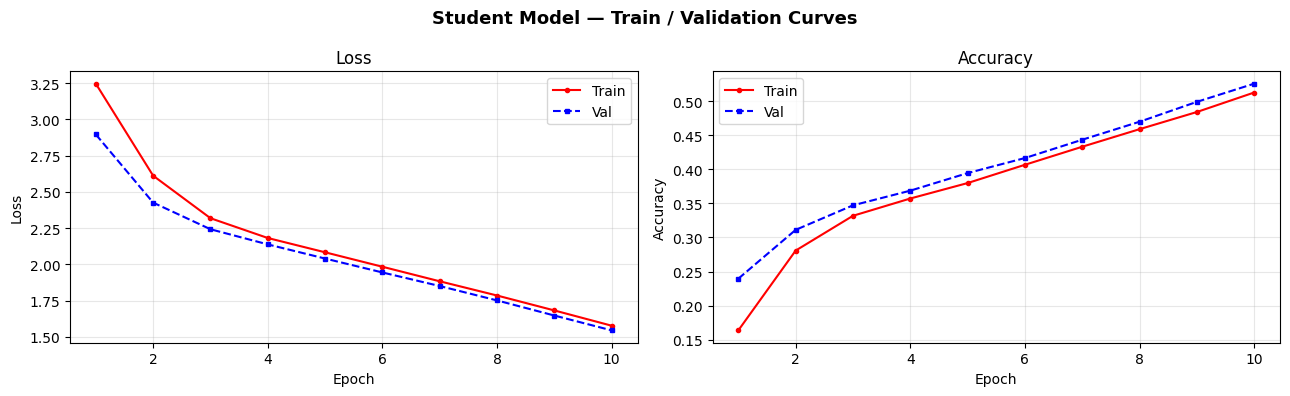


[Auto Grading] Starting 3-run evaluation
  Each run: reinitialize -> 10 epochs -> test loss
  Score based on: best (lowest) loss of 3 runs
  Run 1 (seed=42): test loss = 1.4541
  Run 2 (seed=123): test loss = 1.4752
  Run 3 (seed=777): test loss = 1.4925

  AUTO GRADING RESULT
  Student ID          : 20241234
  Total parameters    : 107,323
  Epochs (student)    : 10
  Run 1/2/3 losses    : 1.4541 / 1.4752 / 1.4925
  Best test loss      : 1.4541  (mean: 1.4739 +- 0.0157)


In [2]:
# ================================================================
# Week 16 Final Exam — Decoder-only Transformer
# Character-level Next Token Prediction (Shakespeare)
#
# [Student Instructions]
#   1. Only modify the MODIFY HERE sections
#   2. Modifying any other section results in 0 points
#   3. Total parameter count MUST be <= 150,000 (auto-checked)
#   4. Before submitting: Runtime > Run all to verify your score
# ================================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ================================================================
# 0. Enter Your Student ID (ensures reproducibility)
# ================================================================
STUDENT_ID = 20241234   # <- Replace with your student ID

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

# ================================================================
# 1. Fixed Hyperparameters — DO NOT MODIFY
# ================================================================
SEQ_LEN     = 64
NUM_SAMPLES = 5_000
MAX_TOKENS  = 50_000
BATCH       = 64
EPOCHS      = 10        # fixed for full-training visualization
SEEDS_EVAL  = [42, 123, 777]
MAX_PARAMS  = 150_000

# ================================================================
# 2. Data Loading — DO NOT MODIFY
# ================================================================
path = tf.keras.utils.get_file(
    'shakespeare.txt',
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt'
)
text        = open(path, 'r').read()[:MAX_TOKENS]
chars       = sorted(set(text))
VOCAB_SIZE  = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for c, i in char_to_idx.items()}
encoded     = np.array([char_to_idx[c] for c in text])

X, y = [], []
for i in range(len(encoded) - SEQ_LEN):
    X.append(encoded[i : i + SEQ_LEN])
    y.append(encoded[i + 1 : i + SEQ_LEN + 1])
X = np.array(X[:NUM_SAMPLES])
y = np.array(y[:NUM_SAMPLES])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Vocab     : {VOCAB_SIZE}")
print(f"Train     : {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ================================================================
# 3. Positional Encoding — DO NOT MODIFY
# ================================================================
def get_positional_encoding(seq_len, d_model):
    pos    = np.arange(seq_len)[:, np.newaxis]
    dim    = np.arange(d_model)[np.newaxis, :]
    angles = pos / np.power(10000, (2 * (dim // 2)) / d_model)
    pe     = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

# ================================================================
# 4. Baseline Model — DO NOT MODIFY (reference only)
#    Single decoder block, no dropout, fixed sinusoidal PE
#    EMBED_DIM=64, FFN_DIM=256, num_heads=4
#    Measured baseline test loss: ~0.75 at 50 epochs (NUM_SAMPLES=20,000)
# ================================================================
class BaselineTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, 64)
        self.pe        = get_positional_encoding(SEQ_LEN, 64)
        self.mha       = tf.keras.layers.MultiHeadAttention(
                             num_heads=4, key_dim=64)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(256, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(64)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE,
                             activation='softmax')

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        a, _ = self.mha(x, x, x,
                        use_causal_mask=True,
                        return_attention_scores=True)
        x = self.norm1(x + a)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        return self.out(x)

# ================================================================
# 5. MODIFY HERE — Your Optimized Model
#
#    Optimization hints (choose any combination):
#      (a) Increase number of decoder blocks  (num_layers)
#      (b) Replace Sinusoidal PE with Learnable PE
#      (c) Add Dropout for regularization
#      (d) Change FFN activation: relu -> gelu
#      (e) Add a Learning Rate schedule
#      (f) Adjust embed_dim or ffn_dim within parameter budget
#
#    Hard constraints (auto-checked):
#      - Total trainable parameters <= 150,000
#      - Causal mask MUST be used  (use_causal_mask=True)
#      - Positional Encoding MUST be included
# ================================================================

class StudentTransformer(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # START modifying below

        EMBED_DIM = 64
        FFN_DIM   = 256

        self.embedding = tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)
        self.pe        = get_positional_encoding(SEQ_LEN, EMBED_DIM)
        self.mha       = tf.keras.layers.MultiHeadAttention(
                             num_heads=4, key_dim=EMBED_DIM)
        self.norm1     = tf.keras.layers.LayerNormalization()
        self.ffn1      = tf.keras.layers.Dense(FFN_DIM, activation='relu')
        self.ffn2      = tf.keras.layers.Dense(EMBED_DIM)
        self.norm2     = tf.keras.layers.LayerNormalization()
        self.out       = tf.keras.layers.Dense(VOCAB_SIZE,
                             activation='softmax')

        # STOP modifying above

    def call(self, x, training=False):
        # START modifying below

        seq_len = tf.shape(x)[1]
        x = self.embedding(x) + self.pe[:, :seq_len, :]
        a, _ = self.mha(x, x, x,
                        use_causal_mask=True,       # DO NOT REMOVE
                        return_attention_scores=True)
        x = self.norm1(x + a)
        x = self.norm2(x + self.ffn2(self.ffn1(x)))
        return self.out(x)

        # STOP modifying above

# ================================================================
# 6. Optimizer and Epochs — YOU MAY CHANGE THIS
# ================================================================
# START modifying below



def get_optimizer():
    return tf.keras.optimizers.Adam(learning_rate=1e-3)
    # Example: cosine decay schedule
    # lr = tf.keras.optimizers.schedules.CosineDecay(1e-3, decay_steps=1500)
    # return tf.keras.optimizers.Adam(lr)

# STOP modifying above

# ================================================================
# 7. Parameter Count Check — DO NOT MODIFY
# ================================================================
def count_params(model, input_shape=(1, SEQ_LEN)):
    model(tf.zeros(input_shape, dtype=tf.int32))
    total = sum(tf.size(v).numpy() for v in model.trainable_variables)
    return total

student_model = StudentTransformer()
n_params = count_params(student_model)
print(f"\nTotal parameters: {n_params:,}")
assert n_params <= MAX_PARAMS, (
    f"[ERROR] Parameter limit exceeded: {n_params:,} > {MAX_PARAMS:,} — cannot grade")
print("[OK] Parameter constraint passed")

# ================================================================
# 8. Full Training (1 run) — for learning curve visualization
# ================================================================
print(f"\n{'='*50}")
print(f"[Full Training] epochs={EPOCHS}")
print(f"{'='*50}")

tf.random.set_seed(STUDENT_ID)
np.random.seed(STUDENT_ID)

student_model = StudentTransformer()
student_model.compile(
    optimizer=get_optimizer(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = student_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

# ================================================================
# 9. Train / Val Curve — DO NOT MODIFY
# ================================================================
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ep, history.history['loss'],     'r-o',  label='Train', markersize=3)
axes[0].plot(ep, history.history['val_loss'], 'b--s', label='Val',   markersize=3)
axes[0].set(title='Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=.3)

axes[1].plot(ep, history.history['accuracy'],     'r-o',  label='Train', markersize=3)
axes[1].plot(ep, history.history['val_accuracy'], 'b--s', label='Val',   markersize=3)
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=.3)

plt.suptitle('Student Model — Train / Validation Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_val_curve.png', dpi=120)
plt.show()

# ================================================================
# 10. Auto Grading — 3-run repeated evaluation — DO NOT MODIFY
#     Each run: reinitialize -> train EPOCHS -> evaluate test loss
#     Final score is based on the BEST (lowest) loss among 3 runs.
# ================================================================
print(f"\n{'='*50}")
print(f"[Auto Grading] Starting {len(SEEDS_EVAL)}-run evaluation")
print(f"  Each run: reinitialize -> {EPOCHS} epochs -> test loss")
print(f"  Score based on: best (lowest) loss of 3 runs")
print(f"{'='*50}")

eval_losses = []

for i, seed in enumerate(SEEDS_EVAL):
    tf.random.set_seed(seed)
    np.random.seed(seed)

    m = StudentTransformer()
    m.compile(
        optimizer=get_optimizer(),
        loss='sparse_categorical_crossentropy'
    )
    m.fit(X_train, y_train,
          epochs=EPOCHS,
          batch_size=BATCH,
          verbose=0)

    result = m.evaluate(X_test, y_test, verbose=0)
    loss = result[0] if isinstance(result, (list, tuple)) else result
    eval_losses.append(loss)
    print(f"  Run {i+1} (seed={seed}): test loss = {loss:.4f}")

best_loss = float(np.min(eval_losses))
mean_loss = float(np.mean(eval_losses))
std_loss  = float(np.std(eval_losses))
# ================================================================
# 11. Score Calculation — DO NOT MODIFY
#
#     Baseline measured: B = 0.75
#     (NUM_SAMPLES=20,000, EPOCHS=50, single decoder block)
# ================================================================

print(f"\n{'='*50}")
print(f"  AUTO GRADING RESULT")
print(f"{'='*50}")
print(f"  Student ID          : {STUDENT_ID}")
print(f"  Total parameters    : {n_params:,}")
print(f"  Epochs (student)    : {EPOCHS}")
print(f"  Run 1/2/3 losses    : {eval_losses[0]:.4f} / {eval_losses[1]:.4f} / {eval_losses[2]:.4f}")
print(f"  Best test loss      : {best_loss:.4f}  (mean: {mean_loss:.4f} +- {std_loss:.4f})")
